Practical Task 4: Titanic Dataset Analysis

## Setup

The next cell loads the data and imports the libraries used throughout the notebook.

In [ ]:
# !pip install --quiet numpy pandas seaborn matplotlib scikit-learn scipy ipython
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# Keep the imported names referenced in this cell so notebook-level lint checks stay quiet.
_ = (np, pd, sns, plt, display, chi2_contingency, KNNImputer, LabelEncoder, RobustScaler, mutual_info_classif, SelectKBest)


def load_titanic_data() -> pd.DataFrame:
    """Load the Titanic passenger manifest from a local CSV if present, otherwise from GitHub raw."""
    local_file = Path("titanic.csv")
    remote_file = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

    if local_file.exists():
        return pd.read_csv(local_file)

    return pd.read_csv(remote_file)


df = load_titanic_data()
original_df = df.copy()

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Tasks 1 to 5: Initial Exploration

This section covers the first five easy tasks: loading the dataset, checking data types, survival rates, missing values, gender-based survival, and embarkation patterns.

Task 1:load the Titanic dataset and display the first 15 rows. Identify which columns contain numerical data and which contain categorical data.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Task 2: Calculate the survival rate (percentage of passengers who survived) overall and separately for each passenger class (1st, 2nd, 3rd). 
Overall survival rate: 38.38%


,Survival Rate (%)
Pclass,
1st Class,62.962963
2nd Class,47.282609
3rd Class,24.236253


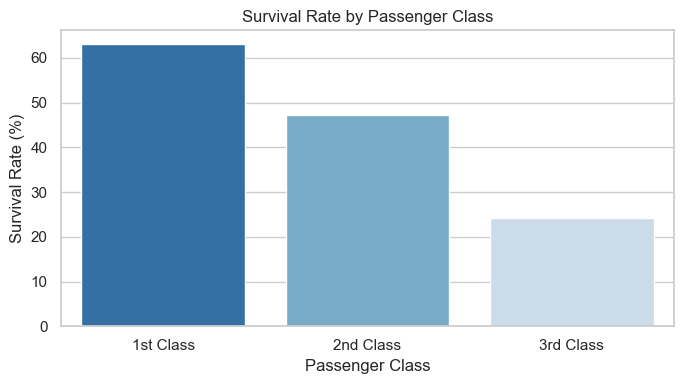

Task 3:Identify all columns with missing values and calculate the percentage of missing data for each column. 


,Missing Percentage
Cabin,77.104377
Age,19.865320
Embarked,0.224467


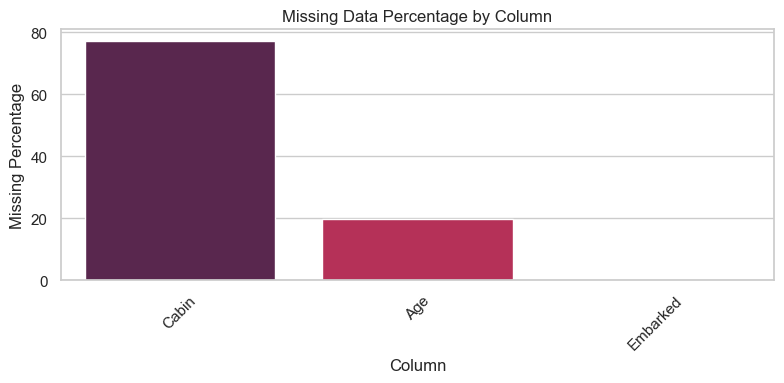

Task 4:Create a count plot showing survival rates by gender. Calculate survival percentages for male and female passengers separately.


,Survival Rate (%)
Sex,
female,74.203822
male,18.890815


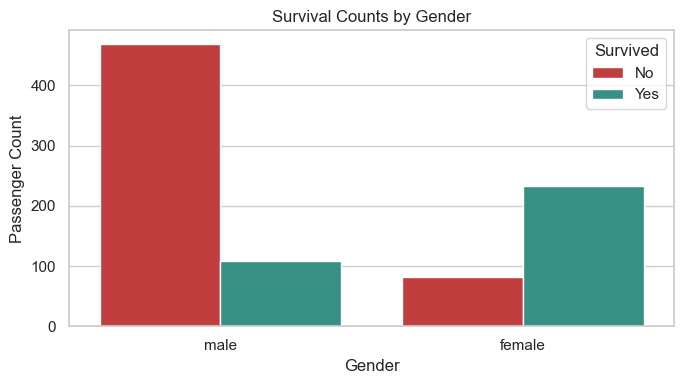

Task 5: Display the unique values in the 'Embarked' column and create a bar chart showing the count of passengers from each port of embarkation. 
Unique values in Embarked: ['C', 'Q', 'S']


,Passenger Count
Embarked,
C,168
Q,77
S,644
NaN,2


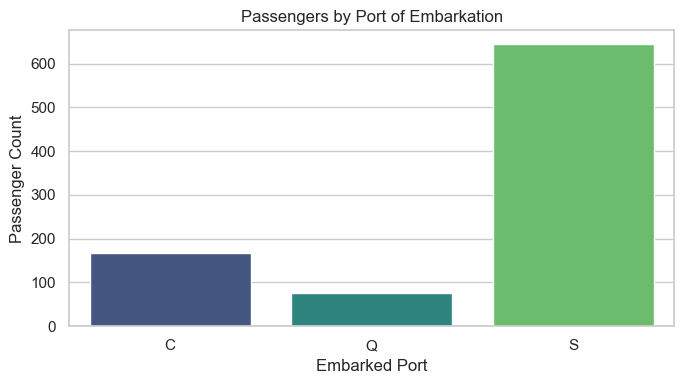

In [11]:
# Task 1: 
print("Task 1:load the Titanic dataset and display the first 15 rows. Identify which columns contain numerical data and which contain categorical data.")

display(df.head(15))

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:")
print(numeric_columns)
print("\nCategorical columns:")
print(categorical_columns)

# Task 2:
print("Task 2: Calculate the survival rate (percentage of passengers who survived) overall and separately for each passenger class (1st, 2nd, 3rd). ")
overall_survival_rate = df["Survived"].mean() * 100
survival_by_class = df.groupby("Pclass")["Survived"].mean().mul(100).rename(index={1: "1st Class", 2: "2nd Class", 3: "3rd Class"})

print(f"Overall survival rate: {overall_survival_rate:.2f}%")
display(survival_by_class.to_frame(name="Survival Rate (%)"))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, palette="Blues_r", ax=ax)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

#task 3:

print("Task 3:Identify all columns with missing values and calculate the percentage of missing data for each column. ")
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

display(missing_percent.to_frame(name="Missing Percentage"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette="rocket", ax=ax)
ax.set_title("Missing Data Percentage by Column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing Percentage")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Task 4:
print("Task 4:Create a count plot showing survival rates by gender. Calculate survival percentages for male and female passengers separately.")

gender_survival = df.groupby("Sex")["Survived"].mean().mul(100).sort_values(ascending=False)
display(gender_survival.to_frame(name="Survival Rate (%)"))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Sex", hue="Survived", palette={0: "#d62828", 1: "#2a9d8f"}, ax=ax)
ax.set_title("Survival Counts by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Passenger Count")
ax.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# Task 5;
print("Task 5: Display the unique values in the 'Embarked' column and create a bar chart showing the count of passengers from each port of embarkation. ")
unique_embarked = sorted(df["Embarked"].dropna().unique().tolist())
print("Unique values in Embarked:", unique_embarked)

embarked_counts = df["Embarked"].value_counts(dropna=False).sort_index()
display(embarked_counts.to_frame(name="Passenger Count"))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=embarked_counts.index.astype(str), y=embarked_counts.values, palette="viridis", ax=ax)
ax.set_title("Passengers by Port of Embarkation")
ax.set_xlabel("Embarked Port")
ax.set_ylabel("Passenger Count")
plt.tight_layout()
plt.show()

### Interpretation

The first-pass exploration usually shows that the dataset is dominated by passenger class, sex, age, fare, and embarkation information. Survival is typically higher in 1st class and among female passengers, while missingness is concentrated in `Age`, `Cabin`, and sometimes `Embarked`.

## Task 6: Age Imputation

This section fills missing values in `Age` using the median age for passengers in the same class and gender group, then compares the age distribution before and after imputation.

Missing Age values before imputation: 177
Missing Age values after imputation: 0


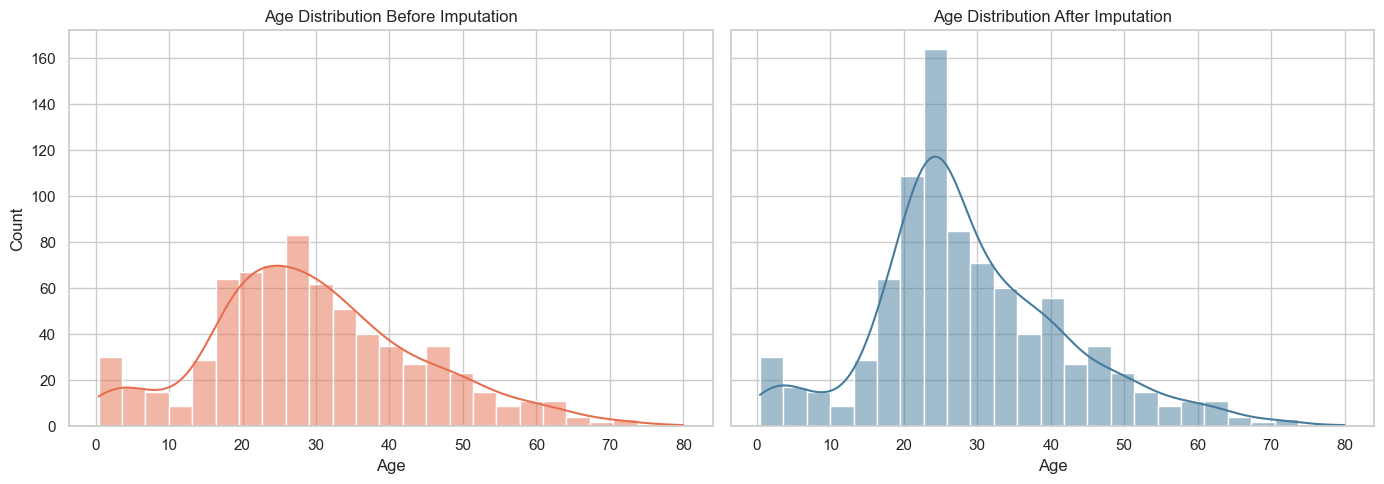

,Pclass,Sex,Age,Age_Imputed
5,3,male,NaN,25.0
17,2,male,NaN,30.0
19,3,female,NaN,21.5
26,3,male,NaN,25.0
28,3,female,NaN,21.5
29,3,male,NaN,25.0
31,1,female,NaN,35.0
32,3,female,NaN,21.5
36,3,male,NaN,25.0
42,3,male,NaN,25.0


In [ ]:
age_before_imputation = df["Age"].copy() # made the duplicate data so that the original dataset remian unchanged and consistent 

age_group_median = df.groupby(["Pclass", "Sex"])["Age"].transform("median")
df["Age_Imputed"] = df["Age"].fillna(age_group_median)
df["Age_Imputed"] = df["Age_Imputed"].fillna(df["Age"].median())

print(f"Missing Age values before imputation: {age_before_imputation.isna().sum()}")
print(f"Missing Age values after imputation: {df['Age_Imputed'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.histplot(age_before_imputation.dropna(), bins=25, kde=True, color="#e76f51", ax=axes[0])
axes[0].set_title("Age Distribution Before Imputation")
axes[0].set_xlabel("Age")

sns.histplot(df["Age_Imputed"], bins=25, kde=True, color="#457b9d", ax=axes[1])
axes[1].set_title("Age Distribution After Imputation")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

sample_imputations = df.loc[df["Age"].isna(), ["Pclass", "Sex", "Age", "Age_Imputed"]].head(10)
display(sample_imputations)

### Interpretation

Median imputation within class and gender keeps the replacement values realistic for each passenger group. The before/after histograms should stay broadly similar, but the imputed version will be complete and ready for modeling.

## Task 7: Encoding Categorical Features

This section applies label encoding to `Sex` and one-hot encoding to `Embarked`, then displays the first 10 transformed rows to verify the result.

In [22]:
encoded_df = df.copy()
sex_encoder = LabelEncoder()
encoded_df["Sex_Encoded"] = sex_encoder.fit_transform(encoded_df["Sex"])

embarked_dummies = pd.get_dummies(encoded_df["Embarked"], prefix="Embarked", dtype=int)
encoded_df = pd.concat([encoded_df, embarked_dummies], axis=1)

encoded_preview_columns = ["Sex", "Sex_Encoded", "Embarked"] + embarked_dummies.columns.tolist()
display(encoded_df[encoded_preview_columns].head(10))


,Sex,Sex_Encoded,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,male,1,S,0,0,1
1,female,0,C,1,0,0
2,female,0,S,0,0,1
3,female,0,S,0,0,1
4,male,1,S,0,0,1
5,male,1,Q,0,1,0
6,male,1,S,0,0,1
7,male,1,S,0,0,1
8,female,0,S,0,0,1
9,female,0,C,1,0,0


### Interpretation

`Sex` is now represented numerically and `Embarked` has been expanded into separate binary columns. This makes the dataset easier to use in machine-learning models without losing the original category information.

## Task 8: Title Extraction from Passenger Names

This section extracts honorific titles from the `Name` column, groups rare titles into `Other`, and compares survival rates across the resulting title groups.

,Name,Title,Title_Grouped
0,"Braund, Mr. Owen Harris",Mr,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Mrs
2,"Heikkinen, Miss. Laina",Miss,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Mrs
4,"Allen, Mr. William Henry",Mr,Mr
5,"Moran, Mr. James",Mr,Mr
6,"McCarthy, Mr. Timothy J",Mr,Mr
7,"Palsson, Master. Gosta Leonard",Master,Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,Mrs


,Survival Rate (%)
Title_Grouped,
Mrs,79.365079
Miss,70.270270
Master,57.500000
Other,34.782609
Mr,15.667311


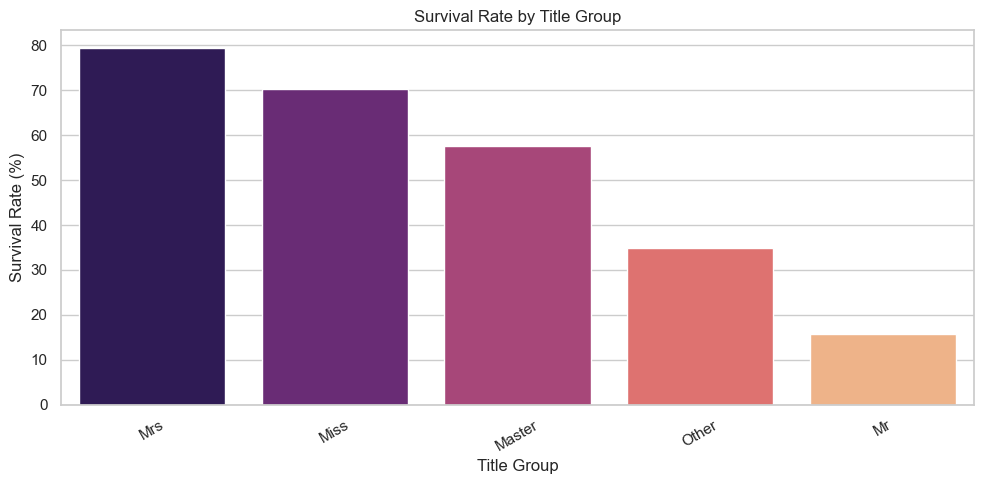

In [14]:
title_df = df.copy()

title_df["Title"] = (
    title_df["Name"]
    .str.extract(r",\s*([^\.]+)\.", expand=False)
    .str.strip()
)

normalized_title_map = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
}
title_df["Title"] = title_df["Title"].replace(normalized_title_map)

rare_title_threshold = 10
title_counts = title_df["Title"].value_counts()
rare_titles = title_counts[title_counts < rare_title_threshold].index
title_df["Title_Grouped"] = title_df["Title"].where(~title_df["Title"].isin(rare_titles), "Other")

title_survival_rate = title_df.groupby("Title_Grouped")["Survived"].mean().mul(100).sort_values(ascending=False)

display(title_df[["Name", "Title", "Title_Grouped"]].head(10))
display(title_survival_rate.to_frame(name="Survival Rate (%)"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=title_survival_rate.index, y=title_survival_rate.values, palette="magma", ax=ax)
ax.set_title("Survival Rate by Title Group")
ax.set_xlabel("Title Group")
ax.set_ylabel("Survival Rate (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Interpretation

The title feature captures social role and family status, which often correlates strongly with survival. Grouping rare titles into `Other` reduces noise while still preserving the signal from unusual honorifics.

## Task 9: Feature Engineering and Chi-square Testing

This section creates `FamilySize`, `IsAlone`, age bands, and `Fare_per_person`, then evaluates the categorical versions of those features with a chi-square test against survival.

,FamilySize,IsAlone,AgeGroup,Fare_per_person
0,2,0,Young Adult,3.62500
1,2,0,Middle Age,35.64165
2,1,1,Young Adult,7.92500
3,2,0,Young Adult,26.55000
4,1,1,Young Adult,8.05000
5,1,1,Missing,8.45830
6,1,1,Middle Age,51.86250
7,5,0,Child,4.21500
8,3,0,Young Adult,3.71110
9,2,0,Child,15.03540


,Feature,Chi2 Statistic,p-value,Degrees of Freedom
3,FarePerPerson_Bin,76.700417,1.565347e-16,3
0,FamilySize_Bin,76.346557,1.864109e-16,3
1,IsAlone,36.000514,1.972654e-09,1
2,AgeGroup,20.211255,4.536541e-04,4


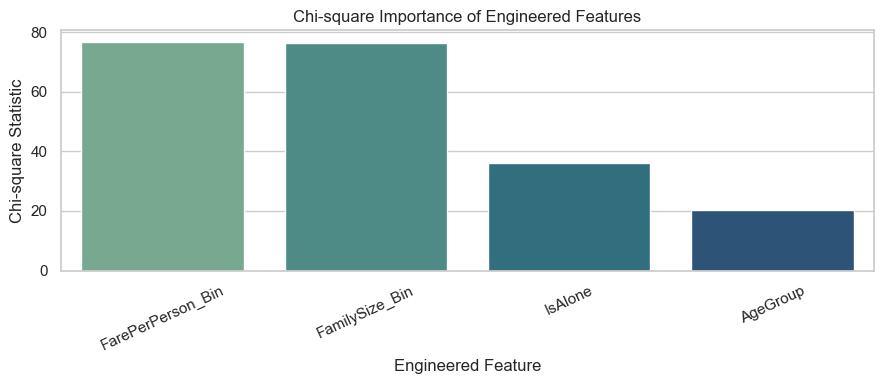

In [ ]:
feature_df = df.copy()

feature_df["FamilySize"] = feature_df["SibSp"] + feature_df["Parch"] + 1
feature_df["IsAlone"] = (feature_df["FamilySize"] == 1).astype(int)
feature_df["Fare_per_person"] = feature_df["Fare"] / feature_df["FamilySize"]


def age_to_group(age_value: float) -> str:
    if pd.isna(age_value):
        return "Missing"
    if age_value < 18:
        return "Child"
    if age_value <= 35:
        return "Young Adult"
    if age_value <= 60:
        return "Middle Age"
    return "Senior"


feature_df["AgeGroup"] = feature_df["Age"].apply(age_to_group)

# Chi-square requires categorical data, so the numeric features are binned before testing.
feature_df["FamilySize_Bin"] = pd.cut(
    feature_df["FamilySize"],
    bins=[0, 1, 4, 7, np.inf],
    labels=["1", "2-4", "5-7", "8+"],
    include_lowest=True,
)
feature_df["FarePerPerson_Bin"] = pd.qcut(
    feature_df["Fare_per_person"].fillna(feature_df["Fare_per_person"].median()),
    q=4,
    duplicates="drop",
)

chi_square_rows = []
for column_name in ["FamilySize_Bin", "IsAlone", "AgeGroup", "FarePerPerson_Bin"]:
    categorical_series = feature_df[column_name].astype("object").where(feature_df[column_name].notna(), "Missing")
    contingency_table = pd.crosstab(categorical_series, feature_df["Survived"])
    chi2_value, p_value, degrees_of_freedom, _ = chi2_contingency(contingency_table)
    chi_square_rows.append(
        {
            "Feature": column_name,
            "Chi2 Statistic": chi2_value,
            "p-value": p_value,
            "Degrees of Freedom": degrees_of_freedom,
        }
    )

chi_square_results = pd.DataFrame(chi_square_rows).sort_values("Chi2 Statistic", ascending=False)

display(feature_df[["FamilySize", "IsAlone", "AgeGroup", "Fare_per_person"]].head(10))
display(chi_square_results)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=chi_square_results, x="Feature", y="Chi2 Statistic", palette="crest", ax=ax)
ax.set_title("Chi-square Importance of Engineered Features")
ax.set_xlabel("Engineered Feature")
ax.set_ylabel("Chi-square Statistic")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Interpretation

`Sex`, family structure, age band, and fare-per-person are all plausible survival drivers, but the chi-square ranking shows which engineered features have the strongest observed association with survival in this dataset.

## Task 10: Complete Preprocessing Pipeline

This final section combines KNN imputation for `Age`, mode filling for `Embarked`, dropping `Cabin`, target encoding for `Embarked`, robust scaling for `Fare`, and mutual-information feature selection.

In [ ]:
pipeline_df = df.copy()

# Feature engineering that will be used for the model-ready table.
pipeline_df["FamilySize"] = pipeline_df["SibSp"] + pipeline_df["Parch"] + 1
pipeline_df["IsAlone"] = (pipeline_df["FamilySize"] == 1).astype(int)
pipeline_df["Fare_per_person"] = pipeline_df["Fare"] / pipeline_df["FamilySize"]
pipeline_df["AgeGroup"] = pipeline_df["Age"].apply(age_to_group)
pipeline_df["AgeGroupCode"] = pipeline_df["AgeGroup"].map(
    {"Missing": -1, "Child": 0, "Young Adult": 1, "Middle Age": 2, "Senior": 3}
).astype(int)

# 3. Drop Cabin because it is too sparse for a stable modeling feature.
pipeline_df = pipeline_df.drop(columns=["Cabin"])

# 1. KNN imputation for Age using nearby passenger features.
knn_input_columns = ["Age", "Pclass", "SibSp", "Parch", "Fare"]
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed = knn_imputer.fit_transform(pipeline_df[knn_input_columns])
pipeline_df["Age_KNN_Imputed"] = knn_imputed[:, 0]

# 2. Fill missing Embarked values with the mode.
embarked_mode = pipeline_df["Embarked"].mode(dropna=True)[0]
pipeline_df["Embarked_Filled"] = pipeline_df["Embarked"].fillna(embarked_mode)

# 4. Target encoding for Embarked based on survival rate.
embarked_target_map = pipeline_df.groupby("Embarked_Filled")["Survived"].mean()
pipeline_df["Embarked_TargetEncoded"] = pipeline_df["Embarked_Filled"].map(embarked_target_map)
pipeline_df["Embarked_TargetEncoded"] = pipeline_df["Embarked_TargetEncoded"].fillna(pipeline_df["Survived"].mean())

# 5. Robust scaling for Fare.
fare_scaler = RobustScaler()
pipeline_df["Fare_RobustScaled"] = fare_scaler.fit_transform(pipeline_df[["Fare"]]).ravel()

# Sex must also be numeric for mutual-information scoring.
sex_encoder_pipeline = LabelEncoder()
pipeline_df["Sex_Encoded"] = sex_encoder_pipeline.fit_transform(pipeline_df["Sex"])

model_features = pipeline_df[
    [
        "Pclass",
        "Sex_Encoded",
        "Age_KNN_Imputed",
        "SibSp",
        "Parch",
        "Fare_RobustScaled",
        "Embarked_TargetEncoded",
        "FamilySize",
        "IsAlone",
        "AgeGroupCode",
        "Fare_per_person",
    ]
].copy()

model_target = pipeline_df["Survived"]

selector = SelectKBest(score_func=mutual_info_classif, k=5)
selector.fit(model_features.fillna(model_features.median(numeric_only=True)), model_target)

mi_scores = pd.Series(selector.scores_, index=model_features.columns).sort_values(ascending=False)
selected_feature_names = model_features.columns[selector.get_support()].tolist()
manual_feature_selection = ["Sex_Encoded", "Pclass", "Age_KNN_Imputed", "Fare_RobustScaled", "Embarked_TargetEncoded"]
comparison_table = pd.DataFrame(
    {
        "Mutual_Info_Top5": selected_feature_names,
        "Manual_Domain_Picks": manual_feature_selection,
    }
)

display(mi_scores.to_frame(name="Mutual Information Score"))
print("Top 5 features selected by mutual information:")
print(selected_feature_names)
print("\nManual feature shortlist based on domain knowledge:")
print(manual_feature_selection)
print("\nOverlap between the two approaches:")
print(sorted(set(selected_feature_names).intersection(manual_feature_selection)))
display(comparison_table)

,Mutual Information Score
Sex_Encoded,0.145135
Fare_RobustScaled,0.143636
Fare_per_person,0.133510
Pclass,0.048637
FamilySize,0.034360
Parch,0.020766
Age_KNN_Imputed,0.020257
Embarked_TargetEncoded,0.014097
AgeGroupCode,0.008289
SibSp,0.006264


Top 5 features selected by mutual information:
['Pclass', 'Sex_Encoded', 'Fare_RobustScaled', 'FamilySize', 'Fare_per_person']

Manual feature shortlist based on domain knowledge:
['Sex_Encoded', 'Pclass', 'Age_KNN_Imputed', 'Fare_RobustScaled', 'Embarked_TargetEncoded']

Overlap between the two approaches:
['Fare_RobustScaled', 'Pclass', 'Sex_Encoded']


,Mutual_Info_Top5,Manual_Domain_Picks
0,Pclass,Sex_Encoded
1,Sex_Encoded,Pclass
2,Fare_RobustScaled,Age_KNN_Imputed
3,FamilySize,Fare_RobustScaled
4,Fare_per_person,Embarked_TargetEncoded


In [ ]:
# this is the dataframe after normalization and feature engineering
original_df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Interpretation

The preprocessing pipeline produces a clean, numeric feature table that is ready for modeling. Mutual information usually highlights the same core Titanic signals seen in the exploratory work: sex, passenger class, fare, family structure, and embarkation behavior.